In [1]:
import os, json, contextlib
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm
import pandas as pd
from scipy.ndimage import affine_transform
from scipy.ndimage import label as cc_label
from scipy.stats import spearmanr
from medpy.metric.binary import hd95 as medpy_hd95
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from transformers import SegformerForSemanticSegmentation, SegformerConfig

SPLITS_DIR = Path(r"D:\master_experiments\data\splits\BraTS2020_Splits")
META_PATH  = SPLITS_DIR / "splits_metadata.json"

SEGFORMER_BASE = Path(r"D:\master_experiments\models_configs\SegFormerB3_2D_BraTS2020")
SEGFORMER_CKPT = SEGFORMER_BASE / "checkpoints"
SEGFORMER_PRED = SEGFORMER_BASE / "predictions_test"
SEGFORMER_LOGS = SEGFORMER_BASE / "logs"
SEGFORMER_DATA = SEGFORMER_BASE / "slice_dataset"

for p in [SEGFORMER_BASE, SEGFORMER_CKPT, SEGFORMER_PRED, SEGFORMER_LOGS,
          SEGFORMER_DATA / "images" / "train", SEGFORMER_DATA / "images" / "val",
          SEGFORMER_DATA / "labels" / "train", SEGFORMER_DATA / "labels" / "val"]:
    p.mkdir(parents=True, exist_ok=True)


MODS      = ["flair", "t1", "t1ce", "t2"]
N_CLASSES = 4
PATCH_2D  = 192
NUM_ITERS_PER_EPOCH = 250

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()
NW      = 0 if os.name == "nt" else 4

print("Device:", DEVICE)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} | VRAM: {props.total_memory/1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER | VRAM: 12.9 GB


In [2]:
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

train_ids = meta["ids"]["train"]
val_ids = meta["ids"]["val"]
test_ids = meta["ids"]["test"]

train_set, val_set, test_set = set(train_ids), set(val_ids), set(test_ids)

assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0

print("Counts:", len(train_ids), len(val_ids), len(test_ids))
print("OK: sem repetição entre splits")

Counts: 245 52 53
OK: sem repetição entre splits


In [3]:
# Funções auxiliares

def case_dir(split_name: str, case_id: str) -> Path:
    return SPLITS_DIR / split_name / case_id

def find_file(folder: Path, key: str) -> Path:
    for cand in [folder / f"{key}.nii.gz", folder / f"{key}.nii"]:
        if cand.exists():
            return cand
    cands = sorted(list(folder.glob(f"*{key}*.nii*")))
    if key == "t1":
        cands = [c for c in cands if "t1ce" not in c.name.lower()]
    if not cands:
        raise FileNotFoundError(f"{key} not found in {folder}")
    return cands[0]

def load_arr(p) -> np.ndarray:
    return np.squeeze(np.asanyarray(nib.load(str(p)).dataobj))

def norm_zscore_fg(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mask = x > 0
    if mask.sum() == 0:
        return np.zeros_like(x)
    mean = float(x[mask].mean())
    std  = float(x[mask].std()) + 1e-8
    out  = (x - mean) / std
    out[~mask] = 0.0
    return out

def norm01(x, p1=1, p99=99) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p1, p99])
    if hi <= lo:
        return np.zeros_like(x)
    return np.clip((x - lo) / (hi - lo), 0, 1)

def load_brats_seg(path) -> np.ndarray:
    data = load_arr(path).astype(np.int16)
    data[data == 4] = 3
    return data

def dice_score(a, b) -> float:
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def pick_best_slice(seg, axis=2) -> int:
    counts = np.sum(seg > 0, axis=tuple(i for i in range(3) if i != axis))
    return int(np.argmax(counts))

for cid in train_ids[:3]:
    d = case_dir("train", cid)
    assert d.exists()
    _ = [find_file(d, m) for m in MODS]
    _ = find_file(d, "seg")
print("Helpers OK")

Helpers OK


In [4]:
# Pre-extracao de slices 2D para .npy (disco) - acelera o treino evitando
# carregar volumes 3D inteiros a cada __getitem__.
#
#  Cada slice axial com lesao vira uma amostra. Background-only slices sao
#  amostradas em 33% para fornecer exemplos negativos sem inflar o dataset.
#  Salva apenas se nao existir ainda (idempotente).

NEG_RATE = 0.33

def export_case_to_slices(cid: str, src_split: str, dst_split: str, rng: np.random.Generator):
    d = case_dir(src_split, cid)
    seg_3d = load_brats_seg(find_file(d, "seg"))
    chans_3d = [norm_zscore_fg(load_arr(find_file(d, m))) for m in MODS]
    H, W, D = seg_3d.shape
    n_saved = 0
    for z in range(D):
        seg2d = seg_3d[:, :, z]
        has_lesion = (seg2d > 0).any()
        if not has_lesion and rng.random() > NEG_RATE:
            continue
        img_path = SEGFORMER_DATA / "images" / dst_split / f"{cid}_z{z:03d}.npy"
        lbl_path = SEGFORMER_DATA / "labels" / dst_split / f"{cid}_z{z:03d}.npy"
        if img_path.exists() and lbl_path.exists():
            n_saved += 1
            continue
        img2d = np.stack([c[:, :, z] for c in chans_3d], axis=0).astype(np.float32)
        np.save(img_path, img2d)
        np.save(lbl_path, seg2d.astype(np.int16))
        n_saved += 1
    return n_saved

rng = np.random.default_rng(42)

tot_tr = 0
for cid in tqdm(train_ids, desc="Export train -> slices"):
    tot_tr += export_case_to_slices(cid, "train", "train", rng)

tot_va = 0
for cid in tqdm(val_ids, desc="Export val -> slices"):
    tot_va += export_case_to_slices(cid, "val", "val", rng)

print(f"Slices train: {tot_tr} | val: {tot_va}")


Export val -> slices: 100%|██████████| 52/52 [01:03<00:00,  1.21s/it]

Slices train: 23308 | val: 5053


In [5]:
class BraTSSliceDataset(Dataset):

    def __init__(self, ids_list, split_name, patch=PATCH_2D,
                 augment=True, num_iterations=None):
        self.ids            = ids_list
        self.split          = split_name
        self.patch          = patch
        self.aug            = augment
        self.num_iterations = num_iterations
        # Lista os .npy do split que pertencem aos ids fornecidos
        ids_set = set(ids_list)
        img_dir = SEGFORMER_DATA / "images" / split_name
        self.slice_files = sorted([
            p for p in img_dir.glob("*.npy")
            if p.stem.rsplit("_z", 1)[0] in ids_set
        ])

    def __len__(self):
        return self.num_iterations if self.num_iterations is not None else len(self.slice_files)

    def _crop_2d(self, arrays, patch):
        seg  = arrays[-1]
        H, W = seg.shape
        half = patch // 2
        if np.random.rand() < 0.33 or not (seg > 0).any():
            cy = np.random.randint(half, max(H - half, half + 1))
            cx = np.random.randint(half, max(W - half, half + 1))
        else:
            coords = np.argwhere(seg > 0)
            cy, cx = coords[np.random.randint(len(coords))]
        cy = int(np.clip(cy, half, H - half))
        cx = int(np.clip(cx, half, W - half))
        return [a[cy-half:cy+half, cx-half:cx+half] for a in arrays]

    def _augment(self, imgs, seg):
        if np.random.rand() < 0.2:
            angle  = np.random.uniform(-30, 30) * np.pi / 180.0
            scale  = np.random.uniform(0.85, 1.25)
            cos_a  = np.cos(angle) / scale
            sin_a  = np.sin(angle) / scale
            matrix = np.array([[ cos_a, sin_a],
                               [-sin_a, cos_a]], dtype=np.float64)
            shape  = np.array(imgs[0].shape)
            center = (shape - 1) / 2.0
            offset = center - matrix @ center
            imgs = [affine_transform(im, matrix, offset=offset, order=1,
                                     mode='constant', cval=0).astype(np.float32)
                    for im in imgs]
            seg  = affine_transform(seg.astype(np.int16), matrix, offset=offset,
                                    order=0, mode='constant', cval=0).astype(np.int16)
        for ax in range(2):
            if np.random.rand() > 0.5:
                imgs = [np.flip(im, axis=ax).copy() for im in imgs]
                seg  = np.flip(seg,  axis=ax).copy()
        bright = np.random.uniform(0.85, 1.15) if np.random.rand() > 0.5 else 1.0
        aug_imgs = []
        for im in imgs:
            im = im * bright
            if np.random.rand() > 0.5:
                im = im + np.random.normal(0, 0.05, im.shape).astype(np.float32)
            aug_imgs.append(im.astype(np.float32))
        return aug_imgs, seg

    def __getitem__(self, idx):
        if self.num_iterations is not None:
            f_img = self.slice_files[np.random.randint(len(self.slice_files))]
        else:
            f_img = self.slice_files[idx]
        f_lbl = SEGFORMER_DATA / "labels" / self.split / f_img.name
        img = np.load(f_img)        # [4, H, W] float32 (z-score ja aplicado no export)
        seg = np.load(f_lbl)        # [H, W] int16
        imgs = [img[c] for c in range(img.shape[0])]
        cropped     = self._crop_2d(imgs + [seg], self.patch)
        imgs, seg   = cropped[:-1], cropped[-1]
        if self.aug:
            imgs, seg = self._augment(imgs, seg)
        vol_t = torch.from_numpy(np.stack(imgs, axis=0).astype(np.float32))
        seg_t = torch.from_numpy(seg.astype(np.int64))
        return vol_t, seg_t


In [6]:
# ═══════════════════════════════════════════════════════════
#  Instanciação do SegFormer-B3 (HuggingFace) para segmentação 2D semântica
# ═══════════════════════════════════════════════════════════
#
#  pretrained = nvidia/segformer-b3-finetuned-ade-512-512
#  encoder    = MiT-B3 (Mix Transformer hierarquico, 4 estagios)
#  decoder    = MLP leve com upsampling para 1/4 da resolucao de entrada
#  num_labels = 4   → bg + NCR + ED + ET (semantica multiclasse)
#  num_channels = 4 → FLAIR, T1, T1ce, T2
#
#  Estrategia para 4 canais (pretrained tem 3):
#    1. Carrega pretrained ADE20K (3 canais) -> referencia de pesos
#    2. Recria com config num_channels=4, num_labels=4 (cabeca de saida
#       e primeira conv ficam com pesos randomicos via ignore_mismatched_sizes)
#    3. Inflate a primeira conv: copia 3 canais pretrained + 4o canal = media dos 3
#       (preserva semantica visual dos pesos pre-treinados na maior parte do encoder)
# ═══════════════════════════════════════════════════════════

SEGFORMER_PRETRAINED = "nvidia/segformer-b3-finetuned-ade-512-512"

# 1. Modelo de referencia (3 canais) para extrair pesos da primeira conv
ref_model = SegformerForSemanticSegmentation.from_pretrained(SEGFORMER_PRETRAINED, use_safetensors=True)
ref_proj  = ref_model.segformer.encoder.patch_embeddings[0].proj
old_w     = ref_proj.weight.data.clone()
old_b     = ref_proj.bias.data.clone() if ref_proj.bias is not None else None

# 2. Configura para 4 canais e N_CLASSES classes
config = SegformerConfig.from_pretrained(SEGFORMER_PRETRAINED)
config.num_labels   = N_CLASSES
config.num_channels = 4

model = SegformerForSemanticSegmentation.from_pretrained(
    SEGFORMER_PRETRAINED,
    config=config,
    ignore_mismatched_sizes=True,
    use_safetensors=True,
)

# 3. Inflate a primeira conv (3 -> 4 canais)
new_proj = model.segformer.encoder.patch_embeddings[0].proj
with torch.no_grad():
    new_w = new_proj.weight.data
    new_w[:, :3, :, :] = old_w
    new_w[:, 3:4, :, :] = old_w.mean(dim=1, keepdim=True)
    new_proj.weight.data = new_w
    if old_b is not None and new_proj.bias is not None:
        new_proj.bias.data = old_b

del ref_model
model = model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

print("=" * 55)
print(f"  SegFormer-B3 (ADE20K pretrained)  —  Configuração do modelo")
print("=" * 55)
print(f"  Canais de entrada (in_channels) : 4 (FLAIR, T1, T1ce, T2)")
print(f"  Canais de saída  (n_classes)    : {N_CLASSES}")
print(f"  Slice 2D                        : {PATCH_2D}x{PATCH_2D}")
print(f"  Device                          : {DEVICE}")
print(f"  Parâmetros treináveis           : {n_params:.2f} M")
print("=" * 55)

Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b3-finetuned-ade-512-512
Key                                              | Status   |                                                                                                     
-------------------------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight                    | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([4, 768, 1, 1])
decode_head.classifier.bias                      | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([4])                      
segformer.encoder.patch_embeddings.0.proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([64, 3, 7, 7]) vs model:torch.Size([64, 4, 7, 7])    

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the orig

  SegFormer-B3 (ADE20K pretrained)  —  Configuração do modelo
  Canais de entrada (in_channels) : 4 (FLAIR, T1, T1ce, T2)
  Canais de saída  (n_classes)    : 4
  Slice 2D                        : 192x192
  Device                          : cuda
  Parâmetros treináveis           : 47.23 M


In [7]:
class DiceCELoss(nn.Module):

    def __init__(self):
        super().__init__()

    def _soft_dice(self, pred_soft, target_oh):
        smooth = 1e-5
        dims   = (0, 2, 3)
        p = pred_soft[:, 1:]
        t = target_oh[:, 1:]
        inter = (p * t).sum(dims)
        denom = p.sum(dims) + t.sum(dims)
        return 1.0 - ((2.0 * inter + smooth) / (denom + smooth)).mean()

    def forward(self, logits, target):
        n_cls = logits.shape[1]
        oh    = F.one_hot(target, n_cls).permute(0, 3, 1, 2).float()
        soft  = torch.softmax(logits, dim=1)
        return self._soft_dice(soft, oh) + F.cross_entropy(logits, target)

In [8]:
TRAIN_EPOCHS = 100
BATCH_SIZE   = 8       # menor que UNet2D (16) por causa do tamanho do SegFormer-B3
ACCUM_STEPS  = 2       # effective batch = 16 (igual ao UNet2D)
LR           = 1e-4    # menor que UNet2D (1e-3) por ser pretrained Transformer
GRAD_CLIP    = 1.0


def train_segformer(model, train_ids, val_ids,
                    epochs=TRAIN_EPOCHS, save_dir=SEGFORMER_CKPT):

    crit   = DiceCELoss()
    scaler = GradScaler("cuda") if USE_AMP else None

    ds_tr = BraTSSliceDataset(train_ids, "train", augment=True,
                              num_iterations=NUM_ITERS_PER_EPOCH * BATCH_SIZE)
    ds_va = BraTSSliceDataset(val_ids,   "val",   augment=False,
                              num_iterations=len(val_ids) * 8)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=NW, pin_memory=USE_AMP)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NW, pin_memory=USE_AMP)

    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)

    tr_losses, va_losses = [], []
    best_val = float("inf")

    for epoch in range(epochs):
        model.train()
        running = 0.0
        opt.zero_grad()

        for step, (vol, seg) in enumerate(
                tqdm(dl_tr, desc=f"Ep {epoch+1:3d}/{epochs} train", leave=False)):
            vol = vol.to(DEVICE)
            seg = seg.to(DEVICE)

            with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                # SegFormer retorna logits em 1/4 da resolucao -> upsample
                out  = model(pixel_values=vol).logits
                out  = F.interpolate(out, size=seg.shape[-2:], mode="bilinear", align_corners=False)
                loss = crit(out, seg) / ACCUM_STEPS

            if scaler:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            if (step + 1) % ACCUM_STEPS == 0:
                if scaler:
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    scaler.step(opt); scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    opt.step()
                opt.zero_grad()

            running += loss.item() * ACCUM_STEPS

        if len(dl_tr) % ACCUM_STEPS != 0:
            if scaler:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(opt); scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
            opt.zero_grad()

        avg_tr = running / max(len(dl_tr), 1)
        tr_losses.append(avg_tr)
        sched.step()

        model.eval()
        running_v = 0.0
        with torch.no_grad():
            for vol, seg in dl_va:
                vol = vol.to(DEVICE); seg = seg.to(DEVICE)
                with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                    out = model(pixel_values=vol).logits
                    out = F.interpolate(out, size=seg.shape[-2:], mode="bilinear", align_corners=False)
                    running_v += crit(out, seg).item()

        avg_va = running_v / max(len(dl_va), 1)
        va_losses.append(avg_va)
        print(f"  Ep {epoch+1:3d} | tr={avg_tr:.4f} | va={avg_va:.4f}")

        if avg_va < best_val:
            best_val = avg_va
            torch.save(model.state_dict(), save_dir / "segformer_best.pth")
            print(f"    ✓ Melhor checkpoint salvo (val={best_val:.4f})")

    history = {"train": tr_losses, "val": va_losses}
    with open(SEGFORMER_LOGS / "train_history.json", "w") as f:
        json.dump(history, f, indent=2)
    print("\nTreino concluído.")
    return history


train_history = train_segformer(model, train_ids, val_ids)

  Ep   1 | tr=1.2516 | va=0.7049
    ✓ Melhor checkpoint salvo (val=0.7049)


  Ep   2 | tr=0.5179 | va=0.4095
    ✓ Melhor checkpoint salvo (val=0.4095)


  Ep   3 | tr=0.3862 | va=0.3604
    ✓ Melhor checkpoint salvo (val=0.3604)


  Ep   4 | tr=0.3451 | va=0.3443
    ✓ Melhor checkpoint salvo (val=0.3443)


  Ep   5 | tr=0.3249 | va=0.3282
    ✓ Melhor checkpoint salvo (val=0.3282)


...

  Ep  96 | tr=0.1896 | va=0.3202


  Ep  97 | tr=0.1774 | va=0.2986


  Ep  98 | tr=0.1913 | va=0.3008


  Ep  99 | tr=0.1905 | va=0.3145


  Ep 100 | tr=0.1830 | va=0.2994

Treino concluído.


In [9]:
def slicewise_inference(model, vol_4ch: np.ndarray, n_classes: int) -> np.ndarray:
    # vol_4ch: [4, H, W, D] - itera ao longo de D (eixo axial), prediz cada fatia 2D e remonta o volume 3D
    model.eval()
    _, H, W, D = vol_4ch.shape

    # SegFormer-B3 requer entrada divisivel por 32 (4 estagios de stride)
    pad_h = (32 - H % 32) % 32
    pad_w = (32 - W % 32) % 32

    pred_3d = np.zeros((H, W, D), dtype=np.int16)

    with torch.no_grad():
        for z in range(D):
            sl = vol_4ch[:, :, :, z]  # [4, H, W]
            if pad_h or pad_w:
                sl = np.pad(sl, ((0, 0), (0, pad_h), (0, pad_w)), mode="constant")
            t = torch.from_numpy(sl[None]).to(DEVICE)  # [1, 4, H', W']
            with autocast("cuda") if USE_AMP else contextlib.nullcontext():
                out = model(pixel_values=t).logits   # [1, n_classes, H'/4, W'/4]
                out = F.interpolate(out, size=t.shape[-2:], mode="bilinear", align_corners=False)
                prob = torch.softmax(out, dim=1)[0].cpu().float().numpy()
            pred_2d = prob.argmax(axis=0).astype(np.int16)
            pred_3d[:, :, z] = pred_2d[:H, :W]

    return pred_3d


print("slicewise_inference OK")

slicewise_inference OK


In [10]:
# Carrega melhor checkpoint e gera predições no conjunto de teste
model.load_state_dict(
    torch.load(SEGFORMER_CKPT / "segformer_best.pth", map_location=DEVICE,
               weights_only=True))
print("Melhor modelo SegFormer-B3 carregado.")

model.eval()
print(f"\nGerando predições → {SEGFORMER_PRED}")

for cid in tqdm(test_ids, desc="Predição test"):
    out_path = SEGFORMER_PRED / f"{cid}.nii.gz"
    d   = case_dir("test", cid)
    ref = nib.load(str(find_file(d, "flair")))
    imgs = [norm_zscore_fg(load_arr(find_file(d, m))) for m in MODS]
    vol  = np.stack(imgs, axis=0).astype(np.float32)  # [4, H, W, D]

    pred = slicewise_inference(model, vol, n_classes=N_CLASSES)  # [H, W, D]
    nib.save(nib.Nifti1Image(pred, ref.affine, ref.header), str(out_path))

print("Predições concluídas.")

Melhor modelo SegFormer-B3 carregado.

Gerando predições → D:\master_experiments\models_configs\SegFormerB3_2D_BraTS2020\predictions_test


Predição test: 100%|██████████| 53/53 [07:51<00:00,  8.90s/it]

Predições concluídas.


In [11]:
# Dice global por caso

def get_pred_path(cid: str) -> Path:
    for ext in [".nii.gz", ".nii"]:
        p = SEGFORMER_PRED / f"{cid}{ext}"
        if p.exists():
            return p
    raise FileNotFoundError(f"Pred não encontrada para {cid}")

def dice(a, b) -> float:
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

rows = []
for cid in tqdm(test_ids, desc="Dice por caso"):
    gt = load_brats_seg(find_file(case_dir("test", cid), "seg"))
    pr = load_arr(get_pred_path(cid)).astype(np.int16)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt==1)|(gt==3)),         ((pr==1)|(pr==3)))

    rows.append({"id": cid,
                 "dice_c1": d1, "dice_c2": d2, "dice_ET": d3,
                 "dice_WT": wt, "dice_TC": tc})

df = pd.DataFrame(rows)
df.to_csv(SEGFORMER_LOGS / "dice_test.csv", index=False)
df.describe()

Dice por caso: 100%|██████████| 53/53 [00:08<00:00,  6.58it/s]


,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,0.655330,0.801737,0.772309,0.890261,0.862967
std,0.275716,0.118163,0.203670,0.087976,0.160833
min,0.000000,0.449780,0.000000,0.582530,0.205148
25%,0.548128,0.725881,0.708585,0.876738,0.839104
50%,0.756056,0.840764,0.840749,0.924450,0.920767
75%,0.861157,0.889881,0.895481,0.943970,0.950882
max,0.971779,0.950141,0.948188,0.965596,0.972566


In [12]:
# HD95 (Hausdorff Distance 95th percentile) por caso — mesmo padrão do Dice global, por regiões

def hd95_score(gt_mask, pr_mask, voxelspacing=None):
    gt_b = gt_mask.astype(bool)
    pr_b = pr_mask.astype(bool)
    if not gt_b.any() and not pr_b.any():
        return 0.0
    if not gt_b.any() or not pr_b.any():
        return np.nan
    return float(medpy_hd95(pr_b, gt_b, voxelspacing=voxelspacing))


hd95_rows = []
for cid in tqdm(test_ids, desc="HD95 por caso"):
    gt_path = find_file(case_dir("test", cid), "seg")
    pr_path = get_pred_path(cid)

    gt = load_brats_seg(gt_path)
    pr = load_arr(pr_path).astype(np.int16)

    spacing = nib.load(str(gt_path)).header.get_zooms()[:3]

    h1  = hd95_score(gt == 1, pr == 1, voxelspacing=spacing)
    h2  = hd95_score(gt == 2, pr == 2, voxelspacing=spacing)
    h3  = hd95_score(gt == 3, pr == 3, voxelspacing=spacing)
    hwt = hd95_score(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)), voxelspacing=spacing)
    htc = hd95_score(((gt == 1) | (gt == 3)),   ((pr == 1) | (pr == 3)),   voxelspacing=spacing)

    hd95_rows.append({
        "id":       cid,
        "hd95_c1":  h1,
        "hd95_c2":  h2,
        "hd95_ET":  h3,
        "hd95_WT":  hwt,
        "hd95_TC":  htc,
    })

df_hd95 = pd.DataFrame(hd95_rows)
df_hd95.to_csv(SEGFORMER_LOGS / "hd95_test.csv", index=False)
df_hd95.describe()

HD95 por caso: 100%|██████████| 53/53 [04:53<00:00,  5.53s/it]


,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,9.042244,8.545717,7.969029,8.198324,6.553526
std,16.038438,15.435130,18.802293,16.121552,15.610504
min,1.000000,1.414214,1.000000,1.414214,1.000000
25%,2.828427,2.000000,1.414214,2.000000,1.414214
50%,4.898979,3.162278,1.732051,3.000000,2.449490
75%,8.306624,6.403124,3.000000,6.395267,4.668848
max,111.359999,95.247572,108.378964,103.768974,110.281458


In [13]:
# Análise condicional 1/3: frequência de presença de cada classe no GT

presence_rows = []
for cid in tqdm(test_ids, desc="Presença GT"):
    gt = load_brats_seg(find_file(case_dir("test", cid), "seg"))
    presence_rows.append({
        "id":     cid,
        "has_c1": bool((gt == 1).any()),
        "has_c2": bool((gt == 2).any()),
        "has_ET": bool((gt == 3).any()),
        "has_WT": bool(((gt==1)|(gt==2)|(gt==3)).any()),
        "has_TC": bool(((gt==1)|(gt==3)).any()),
    })
pres_df = pd.DataFrame(presence_rows)
df_full = df.merge(pres_df, on="id")

df_presence = pd.DataFrame([
    {"classe":     col,
     "n_presente": int(df_full[col].sum()),
     "n_total":    len(df_full),
     "pct":        100.0 * df_full[col].sum() / len(df_full)}
    for col in ["has_c1", "has_c2", "has_ET", "has_WT", "has_TC"]
])
df_presence.round(2)

Presença GT: 100%|██████████| 53/53 [00:02<00:00, 24.81it/s]


,classe,n_presente,n_total,pct
0,has_c1,53,53,100.0
1,has_c2,53,53,100.0
2,has_ET,53,53,100.0
3,has_WT,53,53,100.0
4,has_TC,53,53,100.0


In [14]:
# Análise condicional 2/3: Dice somente nos casos em que a classe está presente no GT
pairs = [("dice_c1","has_c1"), ("dice_c2","has_c2"), ("dice_ET","has_ET"),
         ("dice_WT","has_WT"), ("dice_TC","has_TC")]
df_conditional = pd.DataFrame({
    col: df_full.loc[df_full[has], col].reset_index(drop=True)
    for col, has in pairs
})
df_conditional.to_csv(SEGFORMER_LOGS / "dice_conditional.csv", index=False)
print("\nDice condicional:")
df_conditional.describe().round(4)


Dice condicional:


,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,53.0000,53.0000,53.0000,53.0000,53.0000
mean,0.6553,0.8017,0.7723,0.8903,0.8630
std,0.2757,0.1182,0.2037,0.0880,0.1608
min,0.0000,0.4498,0.0000,0.5825,0.2051
25%,0.5481,0.7259,0.7086,0.8767,0.8391
50%,0.7561,0.8408,0.8407,0.9245,0.9208
75%,0.8612,0.8899,0.8955,0.9440,0.9509
max,0.9718,0.9501,0.9482,0.9656,0.9726


In [15]:
# Análise condicional 3/3: bimodalidade — % de Dice=0 e % de Dice≈1

df_bimodality = pd.DataFrame([
    {"metric":         col,
     "pct_dice_zero": float((df_full[col] == 0.0).mean()) * 100,
     "pct_dice_one":  float((df_full[col] >= 0.999).mean()) * 100}
    for col, _ in pairs
])
df_bimodality.to_csv(SEGFORMER_LOGS / "dice_bimodality.csv", index=False)
df_bimodality.round(2)

,metric,pct_dice_zero,pct_dice_one
0,dice_c1,1.89,0.0
1,dice_c2,0.00,0.0
2,dice_ET,3.77,0.0
3,dice_WT,0.00,0.0
4,dice_TC,0.00,0.0


In [16]:
# Lesion-wise Dice (LWD) — métrica primária do BraTS 2023+

LW_MIN_SIZE = 50

def lesion_wise_dice(gt_mask: np.ndarray, pr_mask: np.ndarray,
                     min_size: int = LW_MIN_SIZE) -> float:
    structure = np.ones((3, 3, 3), dtype=int)
    if not gt_mask.any() and not pr_mask.any():
        return 1.0
    gt_lab, n_gt = cc_label(gt_mask.astype(bool), structure=structure)
    pr_lab, n_pr = cc_label(pr_mask.astype(bool), structure=structure)
    dice_list, matched_pred = [], set()
    for g in range(1, n_gt + 1):
        gt_l = (gt_lab == g)
        if gt_l.sum() < min_size:
            continue
        overlap_ids = np.unique(pr_lab[gt_l])
        overlap_ids = overlap_ids[overlap_ids > 0]
        if len(overlap_ids) == 0:
            dice_list.append(0.0)  # false negative
        else:
            pr_match = np.isin(pr_lab, overlap_ids)
            inter = np.logical_and(gt_l, pr_match).sum()
            denom = gt_l.sum() + pr_match.sum()
            dice_list.append(2.0 * inter / denom if denom > 0 else 0.0)
            matched_pred.update(int(p) for p in overlap_ids)
    for p in range(1, n_pr + 1):
        if p in matched_pred:
            continue
        if (pr_lab == p).sum() < min_size:
            continue
        dice_list.append(0.0)  # false positive
    return float(np.mean(dice_list)) if dice_list else 1.0


lw_rows = []
for cid in tqdm(test_ids, desc="Lesion-wise Dice"):
    gt = load_brats_seg(find_file(case_dir("test", cid), "seg"))
    pr = load_arr(get_pred_path(cid)).astype(np.int16)

    gt_wt = (gt==1)|(gt==2)|(gt==3);  pr_wt = (pr==1)|(pr==2)|(pr==3)
    gt_tc = (gt==1)|(gt==3);          pr_tc = (pr==1)|(pr==3)
    gt_et = (gt==3);                  pr_et = (pr==3)

    lw_rows.append({"id":     cid,
                    "lwd_WT": lesion_wise_dice(gt_wt, pr_wt),
                    "lwd_TC": lesion_wise_dice(gt_tc, pr_tc),
                    "lwd_ET": lesion_wise_dice(gt_et, pr_et)})

lw_df = pd.DataFrame(lw_rows)
lw_df.to_csv(SEGFORMER_LOGS / "dice_lesionwise.csv", index=False)
lw_df[["lwd_WT", "lwd_TC", "lwd_ET"]].describe().round(4)

Lesion-wise Dice: 100%|██████████| 53/53 [00:49<00:00,  1.07it/s]


,lwd_WT,lwd_TC,lwd_ET
count,53.0000,53.0000,53.0000
mean,0.5006,0.7242,0.6602
std,0.2868,0.2640,0.2752
min,0.0699,0.1217,0.0000
25%,0.2958,0.4714,0.4486
50%,0.4516,0.8721,0.7815
75%,0.7728,0.9454,0.8854
max,0.9656,0.9726,0.9482


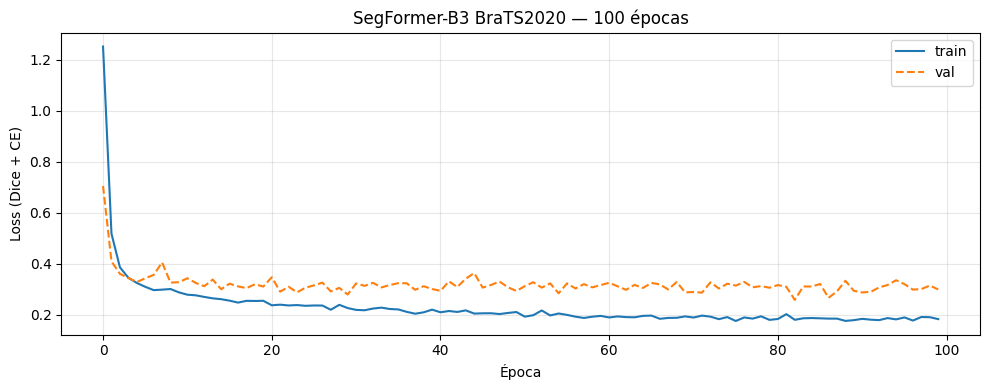

In [17]:
# Curvas de loss (treino vs validação)

hist_path = SEGFORMER_LOGS / "train_history.json"
if "train_history" not in vars():
    if not hist_path.exists():
        raise FileNotFoundError(
            f"Execute a célula de treino primeiro, ou verifique: {hist_path}")
    with open(hist_path) as f:
        train_history = json.load(f)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_history["train"], label="train")
ax.plot(train_history["val"],   label="val", ls="--")
ax.set_xlabel("Época")
ax.set_ylabel("Loss (Dice + CE)")
ax.set_title(f"SegFormer-B3 BraTS2020 — {TRAIN_EPOCHS} épocas")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SEGFORMER_LOGS / "loss_curves.png", dpi=150)
plt.show()


Paciente: BraTS20_Training_182 | split=test | z=89
Dice C1 (necrose/non-enh): 0.6422
Dice C2 (edema):           0.7976
Dice ET (enhancing):       0.8898
Dice WT:                   0.8616
Dice TC:                   0.9035



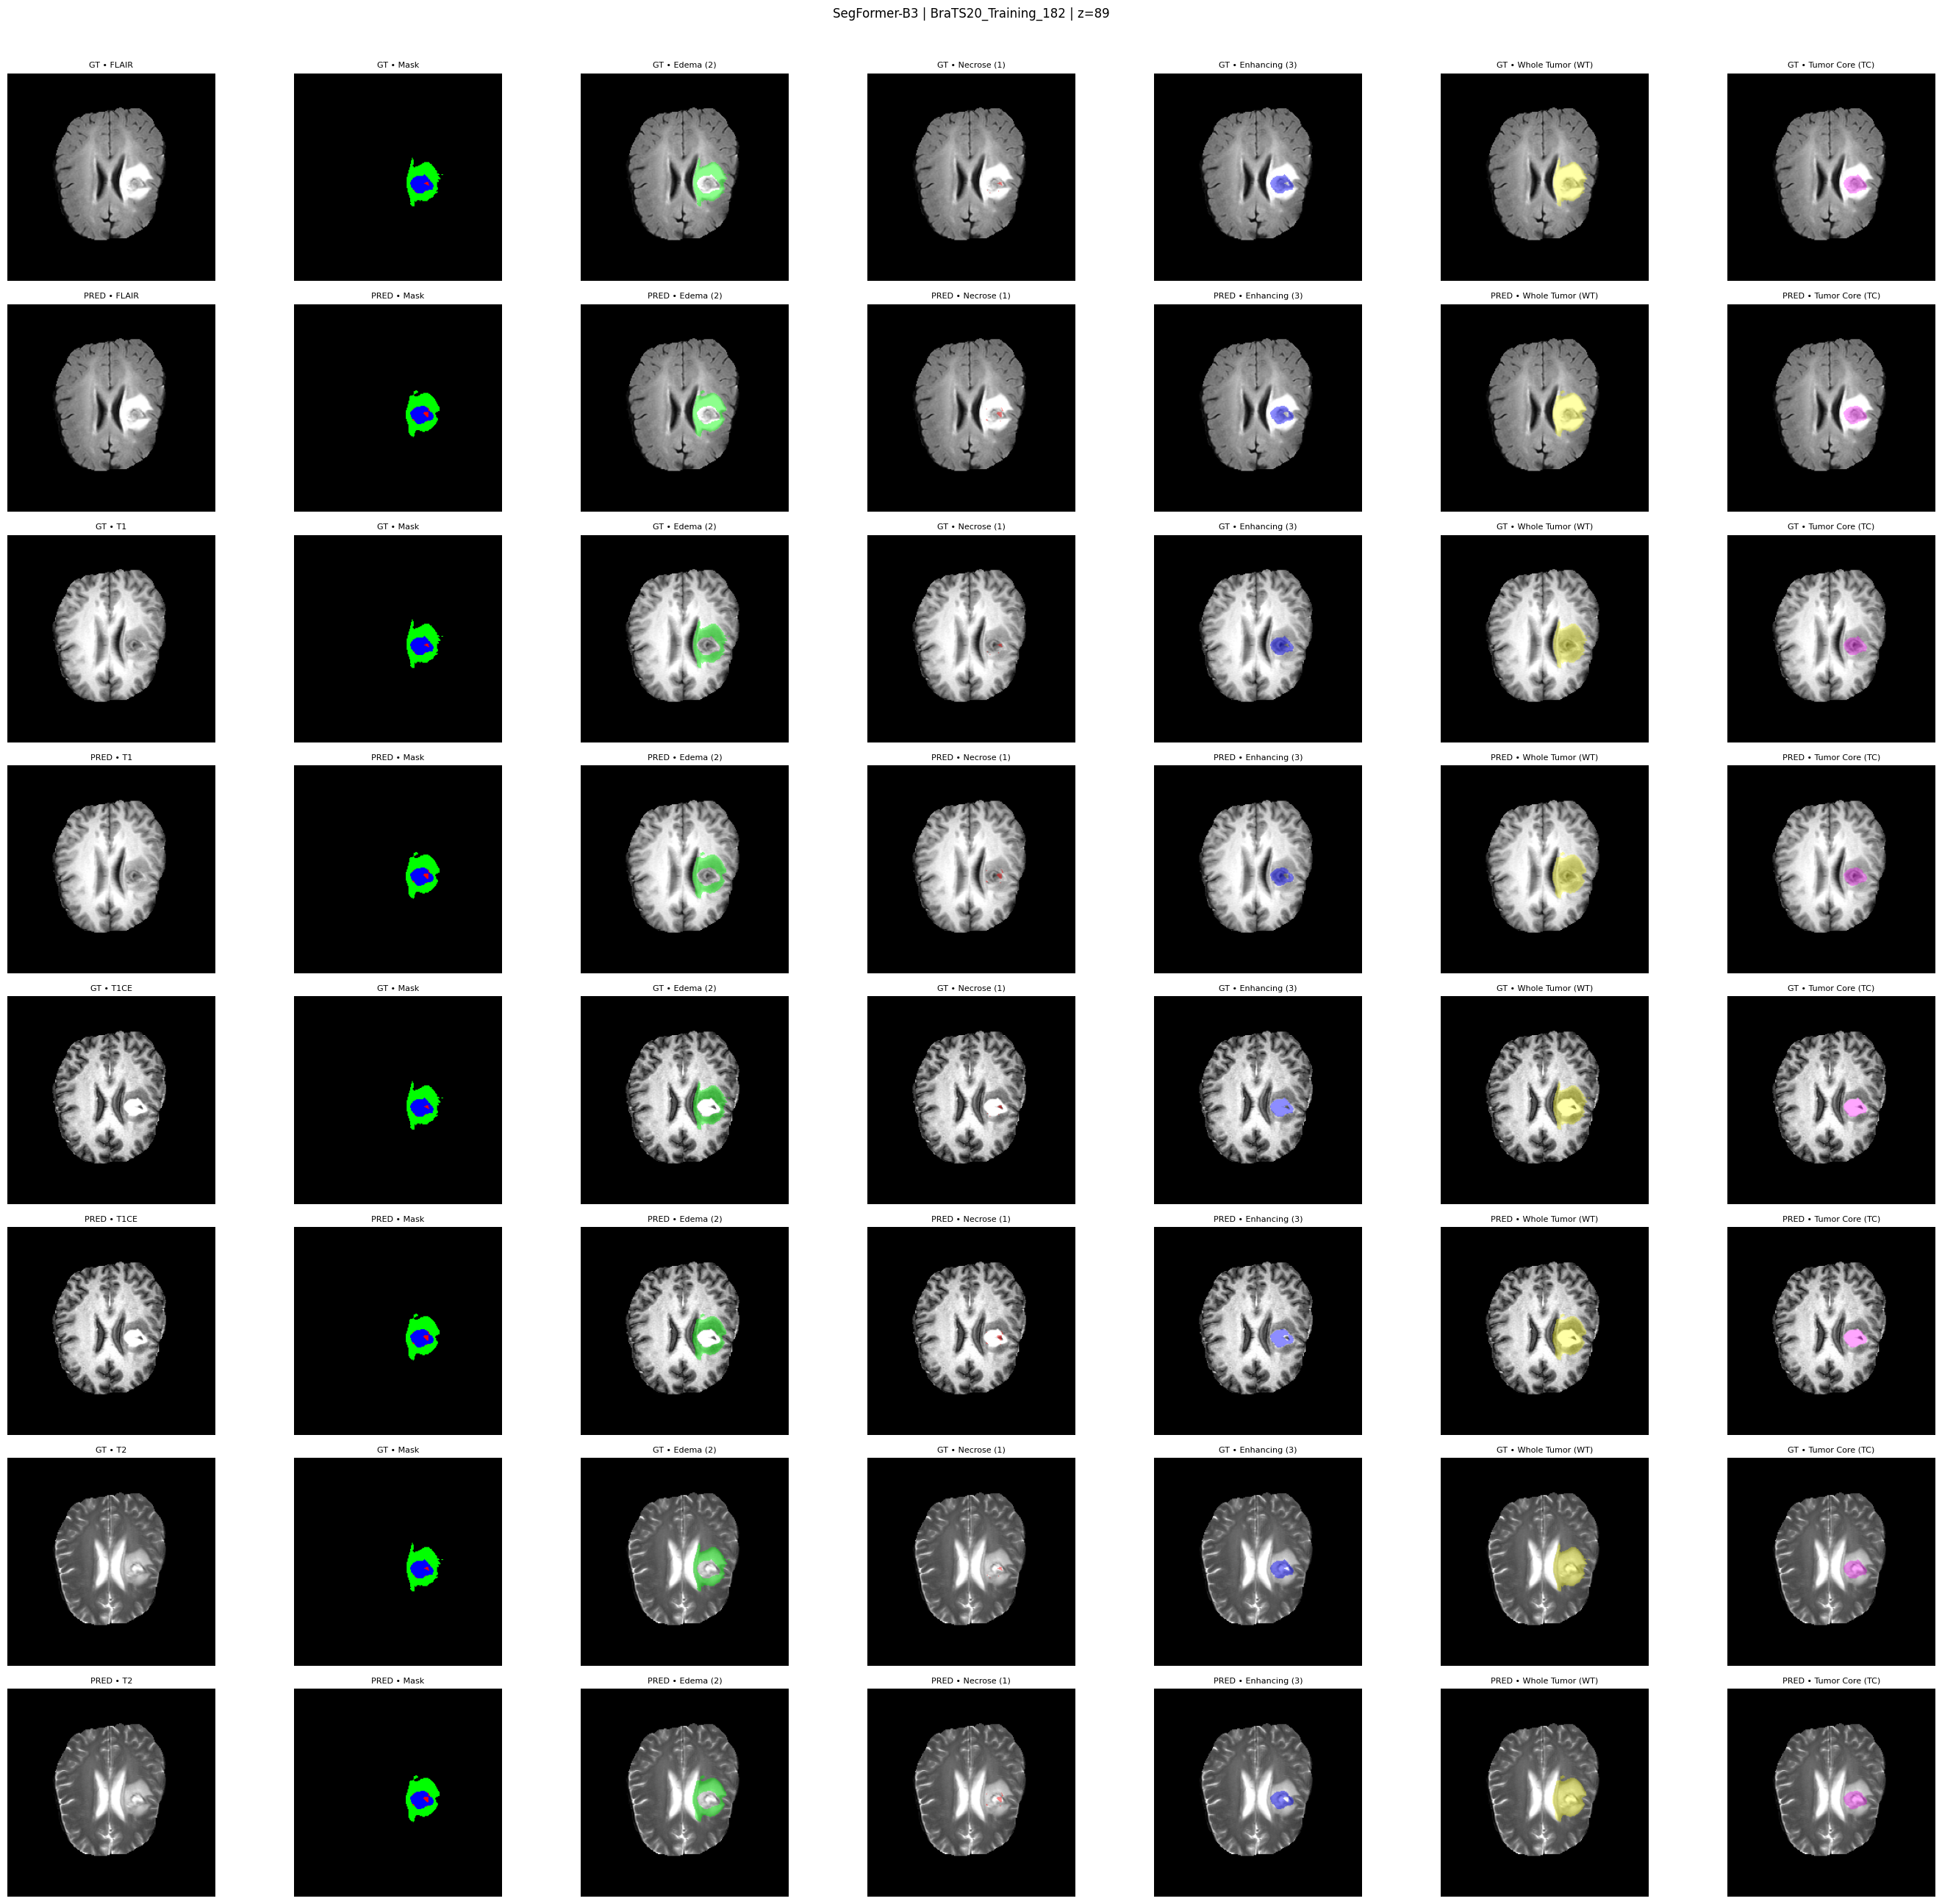

In [28]:
cmap_mask = ListedColormap([(0,0,0,1), (1,0,0,1), (0,1,0,1), (0,0,1,1)])
norm_mask = BoundaryNorm([0, 1, 2, 3, 4], cmap_mask.N)

def masks_from_seg(seg):
    nec = seg == 1; ede = seg == 2; enh = seg == 3
    wt  = (seg==1)|(seg==2)|(seg==3); tc  = (seg==1)|(seg==3)
    return nec, ede, enh, wt, tc

def overlay(ax, base2d, mask2d, color_rgb, alpha=0.45, title=""):
    ax.imshow(base2d, cmap="gray", origin="lower")
    rgba = np.zeros((*mask2d.shape, 4), dtype=np.float32)
    rgba[...,0], rgba[...,1], rgba[...,2] = color_rgb
    rgba[...,3] = mask2d.astype(np.float32) * alpha
    ax.imshow(rgba, origin="lower")
    ax.set_title(title, fontsize=8); ax.axis("off")

def plot_random_case_multimodal_gt_pred(
        ids_list, split_name="test", seed=None, z=None,
        alpha_cls=0.45, alpha_comp=0.35):
    rng = np.random.default_rng(seed)
    cid = str(rng.choice(ids_list))
    d   = case_dir(split_name, cid)

    gt = load_brats_seg(find_file(d, "seg"))
    pr = load_arr(get_pred_path(cid)).astype(np.int16)

    if z is None:
        z = pick_best_slice(gt)

    d1 = dice(gt==1, pr==1); d2 = dice(gt==2, pr==2); d3 = dice(gt==3, pr==3)
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt==1)|(gt==3)),         ((pr==1)|(pr==3)))

    print(f"\nPaciente: {cid} | split={split_name} | z={z}")
    print(f"Dice C1 (necrose/non-enh): {d1:.4f}")
    print(f"Dice C2 (edema):           {d2:.4f}")
    print(f"Dice ET (enhancing):       {d3:.4f}")
    print(f"Dice WT:                   {wt:.4f}")
    print(f"Dice TC:                   {tc:.4f}\n")

    gt2d = gt[:,:,z].T; pr2d = pr[:,:,z].T
    gt_nec,gt_ede,gt_enh,gt_wt,gt_tc = masks_from_seg(gt2d)
    pr_nec,pr_ede,pr_enh,pr_wt,pr_tc = masks_from_seg(pr2d)

    fig, axes = plt.subplots(2*len(MODS), 7, figsize=(28, 3.2*2*len(MODS)))
    fig.suptitle(f"SegFormer-B3 | {cid} | z={z}", y=1.01)

    for i, mod in enumerate(MODS):
        img2d = norm01(load_arr(find_file(d, mod))[:,:,z]).T
        r_gt, r_pr = 2*i, 2*i+1

        axes[r_gt,0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_gt,0].set_title(f"GT • {mod.upper()}", fontsize=8); axes[r_gt,0].axis("off")
        axes[r_gt,1].imshow(gt2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_gt,1].set_title("GT • Mask", fontsize=8); axes[r_gt,1].axis("off")
        overlay(axes[r_gt,2], img2d, gt_ede, (0,1,0), alpha_cls, "GT • Edema (2)")
        overlay(axes[r_gt,3], img2d, gt_nec, (1,0,0), alpha_cls, "GT • Necrose (1)")
        overlay(axes[r_gt,4], img2d, gt_enh, (0,0,1), alpha_cls, "GT • Enhancing (3)")
        overlay(axes[r_gt,5], img2d, gt_wt,  (1,1,0), alpha_comp,"GT • Whole Tumor (WT)")
        overlay(axes[r_gt,6], img2d, gt_tc,  (1,0,1), alpha_comp,"GT • Tumor Core (TC)")

        axes[r_pr,0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_pr,0].set_title(f"PRED • {mod.upper()}", fontsize=8); axes[r_pr,0].axis("off")
        axes[r_pr,1].imshow(pr2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_pr,1].set_title("PRED • Mask", fontsize=8); axes[r_pr,1].axis("off")
        overlay(axes[r_pr,2], img2d, pr_ede, (0,1,0), alpha_cls, "PRED • Edema (2)")
        overlay(axes[r_pr,3], img2d, pr_nec, (1,0,0), alpha_cls, "PRED • Necrose (1)")
        overlay(axes[r_pr,4], img2d, pr_enh, (0,0,1), alpha_cls, "PRED • Enhancing (3)")
        overlay(axes[r_pr,5], img2d, pr_wt,  (1,1,0), alpha_comp,"PRED • Whole Tumor (WT)")
        overlay(axes[r_pr,6], img2d, pr_tc,  (1,0,1), alpha_comp,"PRED • Tumor Core (TC)")

    plt.tight_layout(); plt.show()
    return cid, z, {"dice_c1":d1, "dice_c2":d2, "dice_ET":d3, "dice_WT":wt, "dice_TC":tc}


cid, z, dice_dict = plot_random_case_multimodal_gt_pred(test_ids, split_name="test", seed=None)

In [19]:
# [1/6] Volume tumoral por caso

vol_rows = []
for cid in tqdm(test_ids, desc="Volume tumoral GT"):
    gt_path = find_file(case_dir("test", cid), "seg")
    gt = load_brats_seg(gt_path)
    spacing = nib.load(str(gt_path)).header.get_zooms()[:3]
    voxel_mm3 = float(np.prod(spacing))

    vol_rows.append({
        "id":         cid,
        "vol_WT_mm3": int(((gt==1)|(gt==2)|(gt==3)).sum()) * voxel_mm3,
        "vol_TC_mm3": int(((gt==1)|(gt==3)).sum())         * voxel_mm3,
        "vol_ET_mm3": int((gt==3).sum())                   * voxel_mm3,
    })

df_vol = pd.DataFrame(vol_rows)

df_err = (df.merge(df_hd95, on="id")
            .merge(lw_df,   on="id")
            .merge(df_vol,  on="id"))

df_err.describe().round(3)

Volume tumoral GT: 100%|██████████| 53/53 [00:02<00:00, 18.94it/s]


,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC,lwd_WT,lwd_TC,lwd_ET,vol_WT_mm3,vol_TC_mm3,vol_ET_mm3
count,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000,53.000
mean,0.655,0.802,0.772,0.890,0.863,9.042,8.546,7.969,8.198,6.554,0.501,0.724,0.660,95115.849,38232.642,18346.698
std,0.276,0.118,0.204,0.088,0.161,16.038,15.435,18.802,16.122,15.611,0.287,0.264,0.275,57372.717,30648.866,15950.633
min,0.000,0.450,0.000,0.583,0.205,1.000,1.414,1.000,1.414,1.000,0.070,0.122,0.000,15762.000,1195.000,126.000
25%,0.548,0.726,0.709,0.877,0.839,2.828,2.000,1.414,2.000,1.414,0.296,0.471,0.449,51173.000,11695.000,4362.000
50%,0.756,0.841,0.841,0.924,0.921,4.899,3.162,1.732,3.000,2.449,0.452,0.872,0.781,80396.000,35839.000,17506.000
75%,0.861,0.890,0.895,0.944,0.951,8.307,6.403,3.000,6.395,4.669,0.773,0.945,0.885,135252.000,57282.000,29516.000
max,0.972,0.950,0.948,0.966,0.973,111.360,95.248,108.379,103.769,110.281,0.966,0.973,0.948,231951.000,153111.000,79009.000


In [20]:
# [2/6] Métricas agregadas por quartil de tamanho tumoral (quartiles do volume WT)

q25, q50, q75 = df_err["vol_WT_mm3"].quantile([0.25, 0.50, 0.75]).values

def size_bin(v):
    if v < q25: return "Q1"
    if v < q50: return "Q2"
    if v < q75: return "Q3"
    return "Q4"

df_err["size_bin"] = df_err["vol_WT_mm3"].apply(size_bin)

agg_cols = ["dice_WT", "dice_TC", "dice_ET",
            "hd95_WT", "hd95_TC", "hd95_ET",
            "lwd_WT",  "lwd_TC",  "lwd_ET"]

print(f"Limiares (vol WT em mm³): Q1 < {q25:,.0f}  |  Q2 < {q50:,.0f}  |  Q3 < {q75:,.0f}  |  Q4 ≥ {q75:,.0f}")
print(f"Contagem por quartil: {df_err['size_bin'].value_counts().to_dict()}\n")

df_err.groupby("size_bin")[agg_cols].mean().reindex(["Q1", "Q2", "Q3", "Q4"]).round(4)

Limiares (vol WT em mm³): Q1 < 51,173  |  Q2 < 80,396  |  Q3 < 135,252  |  Q4 ≥ 135,252
Contagem por quartil: {'Q4': 14, 'Q1': 13, 'Q2': 13, 'Q3': 13}



,dice_WT,dice_TC,dice_ET,hd95_WT,hd95_TC,hd95_ET,lwd_WT,lwd_TC,lwd_ET
size_bin,,,,,,,,,
Q1,0.7869,0.7817,0.7730,19.4919,14.6173,12.5088,0.4355,0.6297,0.6818
Q2,0.9128,0.9062,0.7289,5.2508,2.5910,8.0140,0.4195,0.8241,0.6853
Q3,0.9238,0.9255,0.8463,5.0102,3.3934,1.9386,0.5333,0.7623,0.7350
Q4,0.9342,0.8403,0.7432,3.4088,5.6795,9.3114,0.6060,0.6836,0.5474


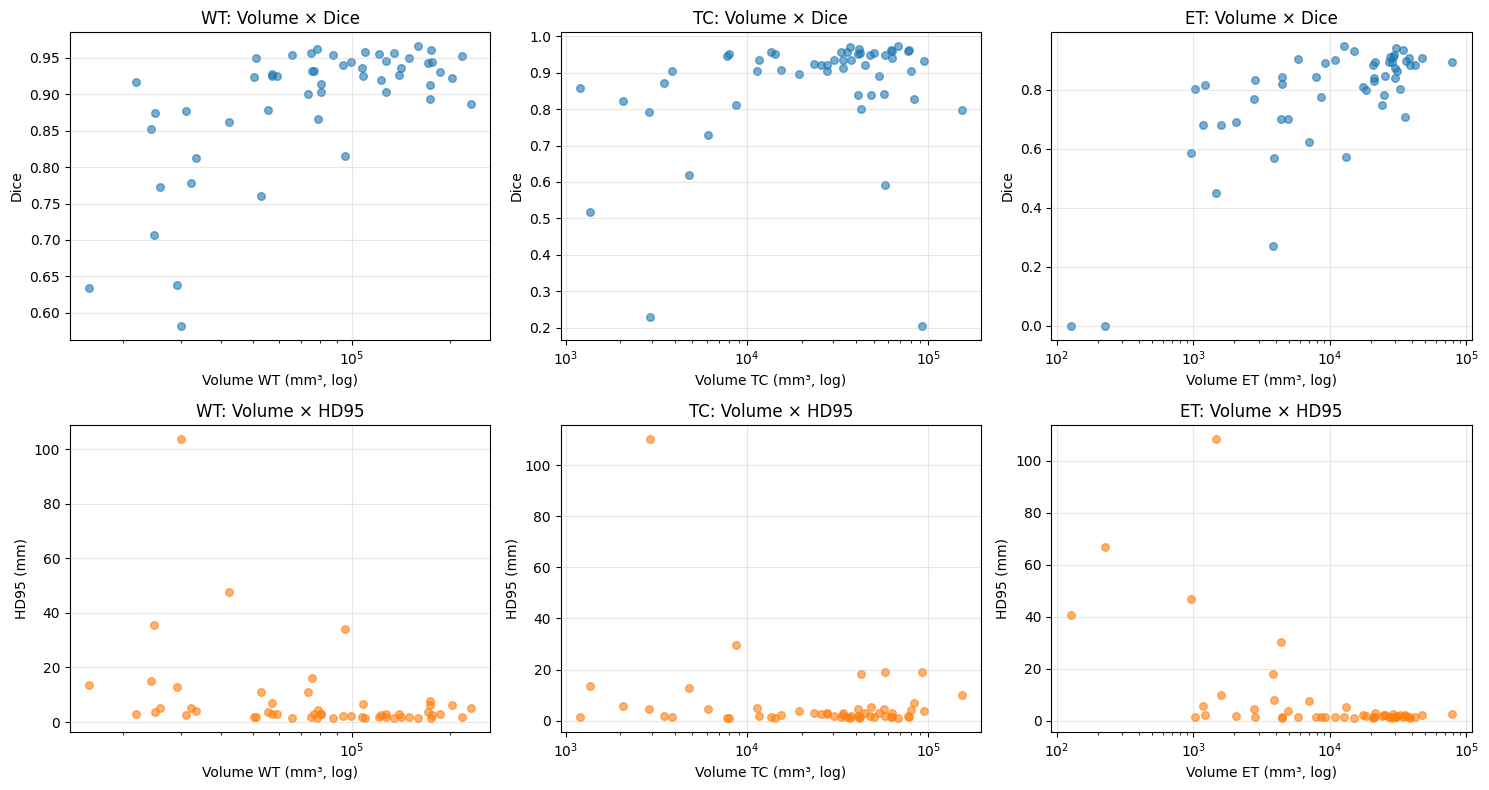

In [21]:
# [3/6] Scatter: volume tumoral × Dice e × HD95 (por região)

regions = ["WT", "TC", "ET"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for j, reg in enumerate(regions):
    vol = df_err[f"vol_{reg}_mm3"].values
    dsc = df_err[f"dice_{reg}"].values
    hsc = df_err[f"hd95_{reg}"].values

    axes[0, j].scatter(vol, dsc, alpha=0.6, s=30)
    axes[0, j].set_xscale("log")
    axes[0, j].set_xlabel(f"Volume {reg} (mm³, log)")
    axes[0, j].set_ylabel("Dice")
    axes[0, j].set_title(f"{reg}: Volume × Dice")
    axes[0, j].grid(True, alpha=0.3)

    axes[1, j].scatter(vol, hsc, alpha=0.6, s=30, color="C1")
    axes[1, j].set_xscale("log")
    axes[1, j].set_xlabel(f"Volume {reg} (mm³, log)")
    axes[1, j].set_ylabel("HD95 (mm)")
    axes[1, j].set_title(f"{reg}: Volume × HD95")
    axes[1, j].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [22]:
# [3/6] Correlação de Spearman entre volume tumoral e métricas

corr_rows = []
for reg in regions:
    v = df_err[f"vol_{reg}_mm3"].values
    d = df_err[f"dice_{reg}"].values
    h = df_err[f"hd95_{reg}"].values

    rho_d, p_d = spearmanr(v, d)
    mask = ~np.isnan(h)
    if mask.sum() > 2:
        rho_h, p_h = spearmanr(v[mask], h[mask])
    else:
        rho_h, p_h = np.nan, np.nan

    corr_rows.append({
        "regiao": reg,
        "spearman_vol×dice": round(rho_d, 3),  "p_value_dice": round(p_d, 4),
        "spearman_vol×hd95": round(rho_h, 3),  "p_value_hd95": round(p_h, 4),
    })

print("Correlação de Spearman entre volume tumoral e métricas:")
pd.DataFrame(corr_rows)

Correlação de Spearman entre volume tumoral e métricas:


,regiao,spearman_vol×dice,p_value_dice,spearman_vol×hd95,p_value_hd95
0,WT,0.560,0.0000,-0.375,0.0057
1,TC,0.284,0.0396,0.012,0.9325
2,ET,0.644,0.0000,-0.405,0.0026


In [23]:
# [4/6] Ranking dos piores casos por Dice médio (WT/TC/ET)

K_WORST = 5

df_err["dice_mean"] = df_err[["dice_WT", "dice_TC", "dice_ET"]].mean(axis=1)
df_err["hd95_mean"] = df_err[["hd95_WT", "hd95_TC", "hd95_ET"]].mean(axis=1, skipna=True)

cols_show = ["id", "dice_WT", "dice_TC", "dice_ET",
             "hd95_WT", "hd95_TC", "hd95_ET",
             "vol_WT_mm3", "vol_ET_mm3", "size_bin"]

print(f"Top {K_WORST} piores casos por Dice médio:")
worst_dice = df_err.nsmallest(K_WORST, "dice_mean")[cols_show + ["dice_mean"]].round(3)
worst_ids = worst_dice["id"].tolist()

worst_dice

Top 5 piores casos por Dice médio:


,id,dice_WT,dice_TC,dice_ET,hd95_WT,hd95_TC,hd95_ET,vol_WT_mm3,vol_ET_mm3,size_bin,dice_mean
1,BraTS20_Training_277,0.583,0.228,0.450,103.769,110.281,108.379,30073.0,1463.0,Q1,0.420
48,BraTS20_Training_316,0.887,0.205,0.682,5.099,19.026,9.992,231951.0,1585.0,Q4,0.591
49,BraTS20_Training_291,0.953,0.841,0.000,2.000,4.690,40.465,218263.0,126.0,Q4,0.598
18,BraTS20_Training_271,0.950,0.923,0.000,2.000,2.828,66.970,51173.0,224.0,Q2,0.624
45,BraTS20_Training_301,0.893,0.591,0.569,6.325,19.105,7.969,173216.0,3873.0,Q4,0.684


In [24]:
# [4/6] Ranking dos piores casos por HD95 médio

print(f"Top {K_WORST} piores casos por HD95 médio:")
df_err.nlargest(K_WORST, "hd95_mean")[cols_show + ["hd95_mean"]].round(3)

Top 5 piores casos por HD95 médio:


,id,dice_WT,dice_TC,dice_ET,hd95_WT,hd95_TC,hd95_ET,vol_WT_mm3,vol_ET_mm3,size_bin,hd95_mean
1,BraTS20_Training_277,0.583,0.228,0.450,103.769,110.281,108.379,30073.0,1463.0,Q1,107.476
3,BraTS20_Training_159,0.852,0.813,0.702,15.166,29.602,30.356,24434.0,4362.0,Q1,25.041
18,BraTS20_Training_271,0.950,0.923,0.000,2.000,2.828,66.970,51173.0,224.0,Q2,23.933
47,BraTS20_Training_313,0.943,0.827,0.585,3.606,7.071,46.872,171033.0,957.0,Q4,19.183
19,BraTS20_Training_182,0.862,0.904,0.890,47.557,5.000,1.414,42233.0,9134.0,Q1,17.990



Paciente: BraTS20_Training_277 | split=test | z=78
Dice C1 (necrose/non-enh): 0.0238
Dice C2 (edema):           0.5980
Dice ET (enhancing):       0.4502
Dice WT:                   0.5825
Dice TC:                   0.2278



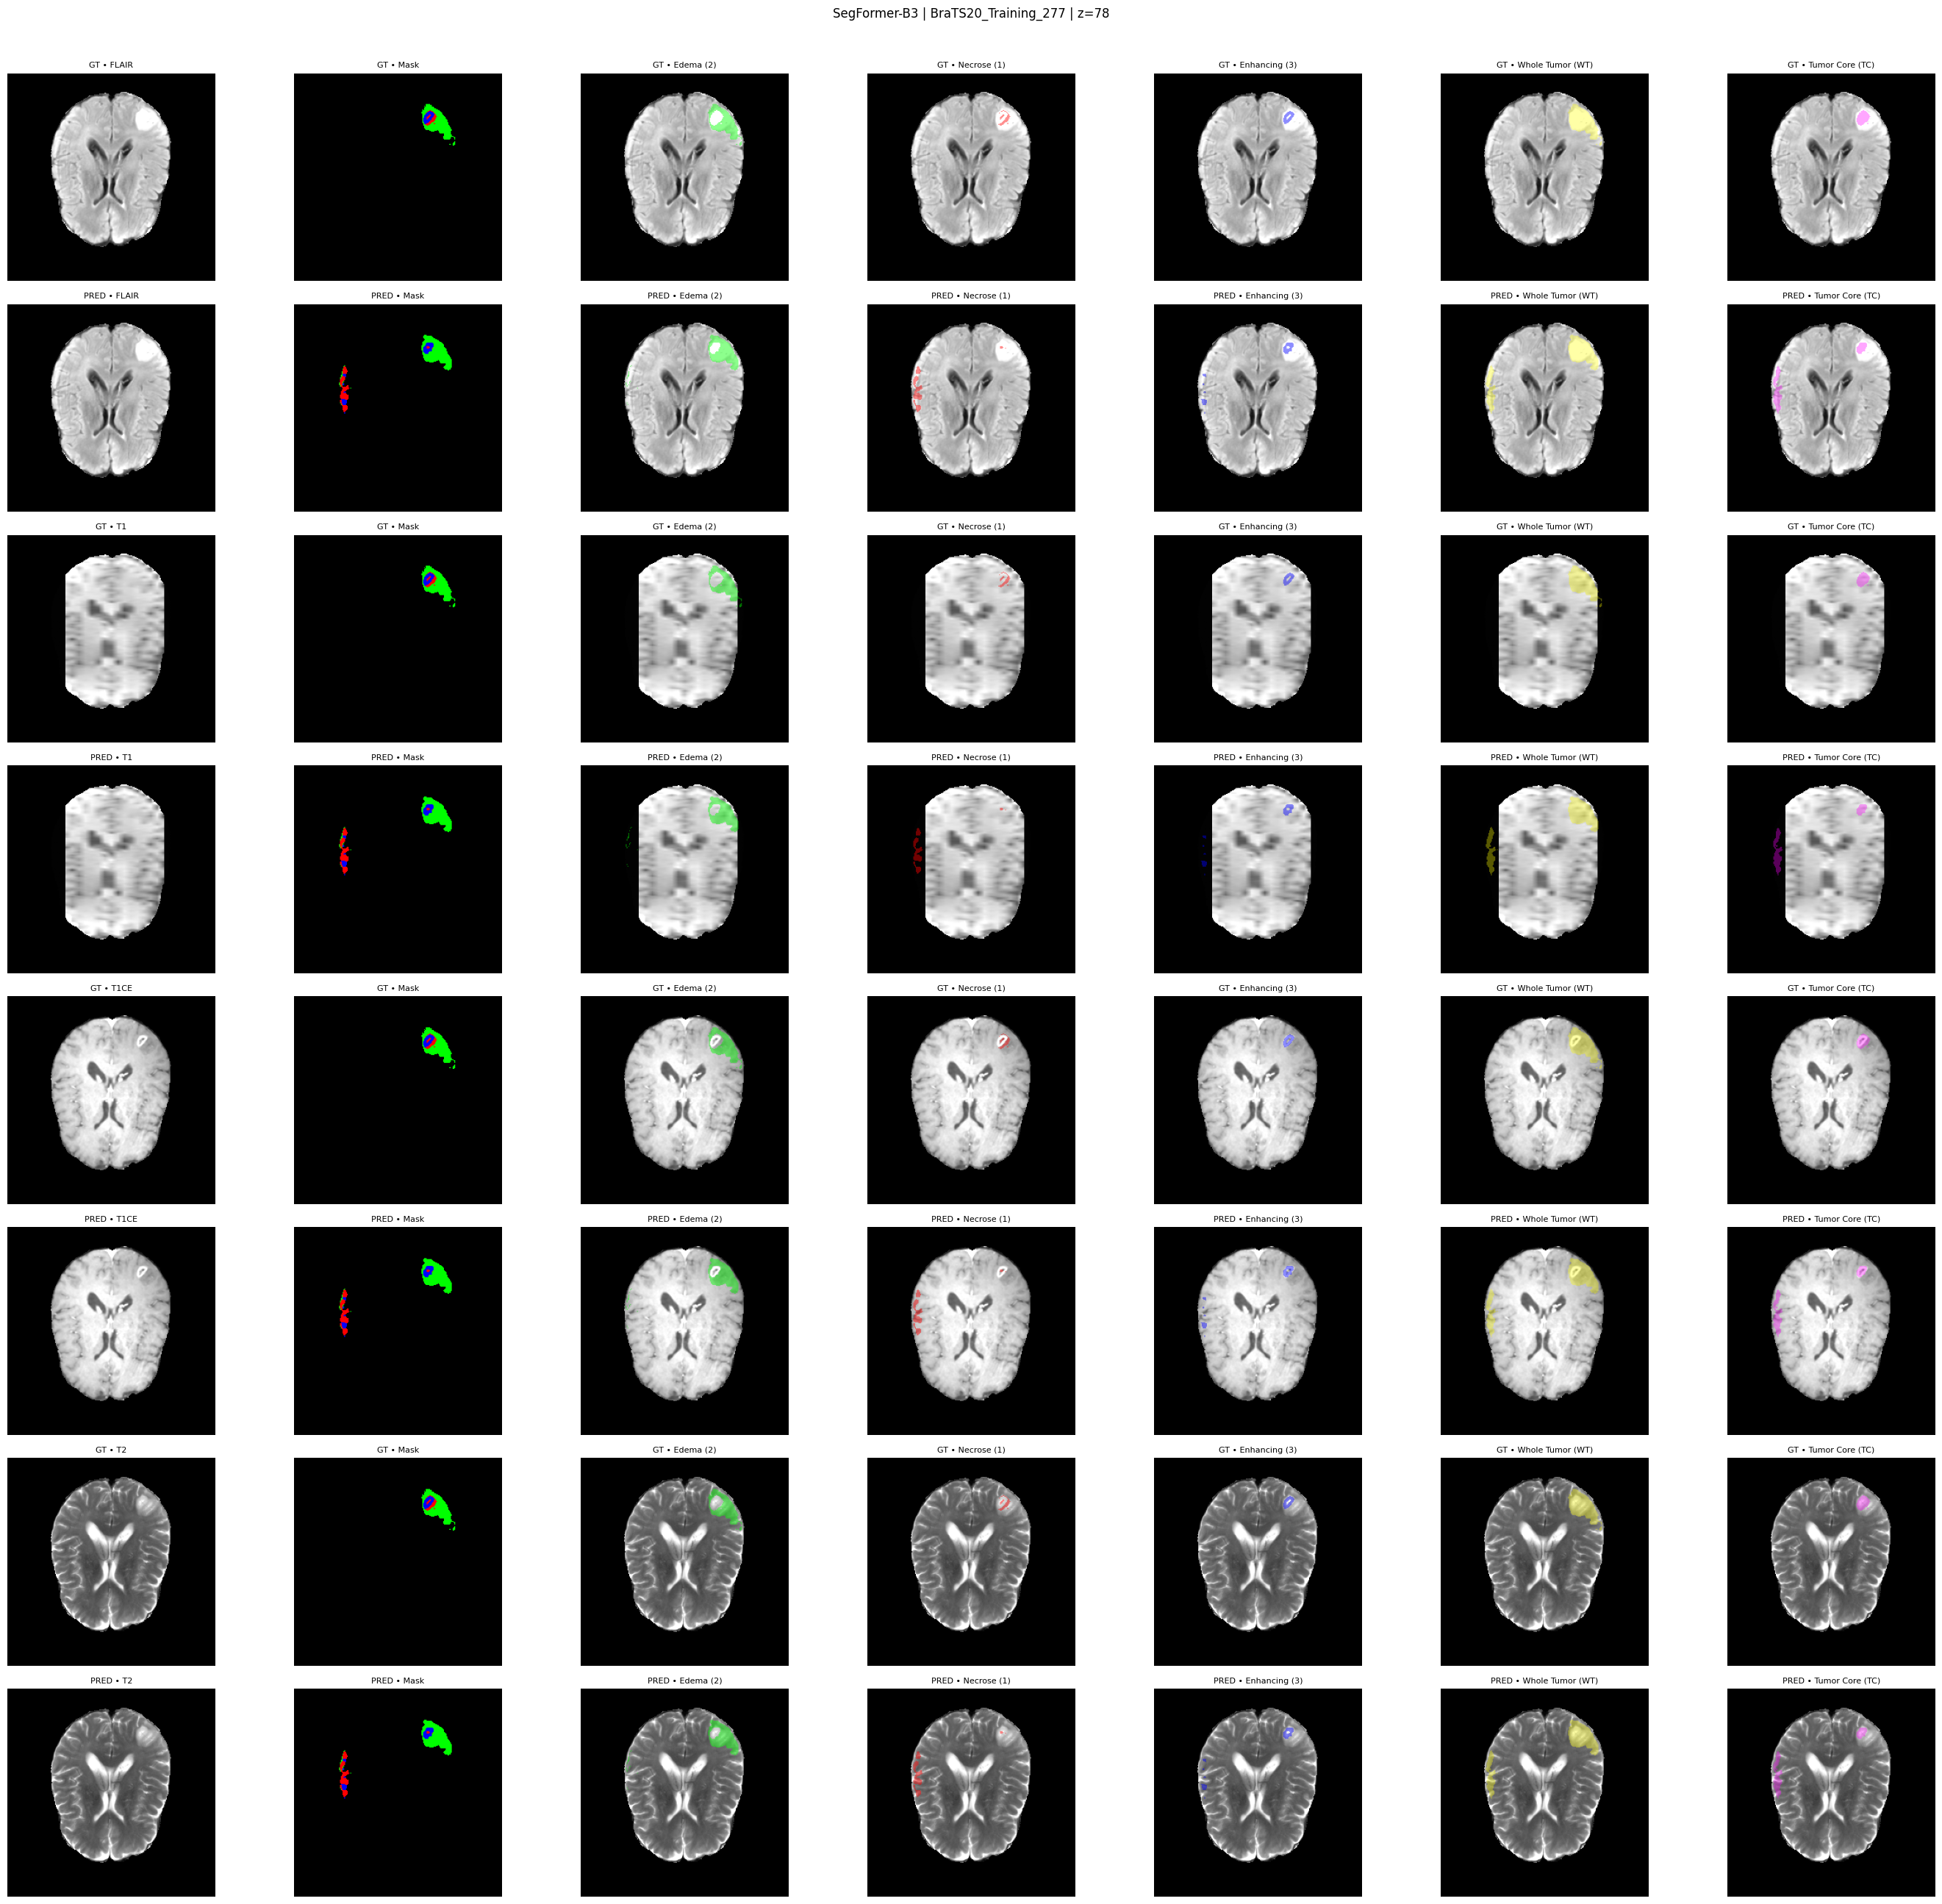

In [25]:
# [5/6] Visualização qualitativa dos piores casos

N_PLOT = min(1, len(worst_ids))

for cid in worst_ids[:N_PLOT]:
    plot_random_case_multimodal_gt_pred([cid], split_name="test", seed=0)

In [26]:
# [6/6] Análise de componentes conexos: lesões perdidas (FN) vs (FP) por caso

CC_MIN_SIZE = 50

def count_components(gt_mask, pr_mask, min_size=CC_MIN_SIZE):
    structure = np.ones((3, 3, 3), dtype=int)
    gt_lab, n_gt = cc_label(gt_mask.astype(bool), structure=structure)
    pr_lab, n_pr = cc_label(pr_mask.astype(bool), structure=structure)

    n_gt_valid = sum(1 for g in range(1, n_gt + 1) if (gt_lab == g).sum() >= min_size)
    n_pr_valid = sum(1 for p in range(1, n_pr + 1) if (pr_lab == p).sum() >= min_size)

    matched_pred, n_missed = set(), 0
    for g in range(1, n_gt + 1):
        gt_l = (gt_lab == g)
        if gt_l.sum() < min_size:
            continue
        overlap = np.unique(pr_lab[gt_l]); overlap = overlap[overlap > 0]
        if len(overlap) == 0:
            n_missed += 1
        else:
            matched_pred.update(int(p) for p in overlap)

    n_spurious = sum(1 for p in range(1, n_pr + 1)
                     if p not in matched_pred and (pr_lab == p).sum() >= min_size)
    return n_gt_valid, n_pr_valid, n_missed, n_spurious


cc_rows = []
for cid in tqdm(test_ids, desc="Componentes conexos"):
    gt = load_brats_seg(find_file(case_dir("test", cid), "seg"))
    pr = load_arr(get_pred_path(cid)).astype(np.int16)

    nw = count_components((gt==1)|(gt==2)|(gt==3), (pr==1)|(pr==2)|(pr==3))
    nt = count_components((gt==1)|(gt==3),         (pr==1)|(pr==3))
    ne = count_components((gt==3),                  (pr==3))

    cc_rows.append({"id": cid,
        "WT_n_gt": nw[0], "WT_n_pr": nw[1], "WT_missed_FN": nw[2], "WT_spurious_FP": nw[3],
        "TC_n_gt": nt[0], "TC_n_pr": nt[1], "TC_missed_FN": nt[2], "TC_spurious_FP": nt[3],
        "ET_n_gt": ne[0], "ET_n_pr": ne[1], "ET_missed_FN": ne[2], "ET_spurious_FP": ne[3],
    })

df_cc = pd.DataFrame(cc_rows)

totals = pd.DataFrame({
    "região":          ["WT", "TC", "ET"],
    "tot_lesões_GT":   [df_cc["WT_n_gt"].sum(),       df_cc["TC_n_gt"].sum(),       df_cc["ET_n_gt"].sum()],
    "tot_lesões_PR":   [df_cc["WT_n_pr"].sum(),       df_cc["TC_n_pr"].sum(),       df_cc["ET_n_pr"].sum()],
    "tot_perdidas_FN": [df_cc["WT_missed_FN"].sum(),  df_cc["TC_missed_FN"].sum(),  df_cc["ET_missed_FN"].sum()],
    "tot_espúrias_FP": [df_cc["WT_spurious_FP"].sum(),df_cc["TC_spurious_FP"].sum(),df_cc["ET_spurious_FP"].sum()],
})
totals["FN_rate_%"] = (100 * totals["tot_perdidas_FN"] / totals["tot_lesões_GT"].replace(0, np.nan)).round(2)
totals["FP_rate_%"] = (100 * totals["tot_espúrias_FP"] / totals["tot_lesões_PR"].replace(0, np.nan)).round(2)

totals

Componentes conexos: 100%|██████████| 53/53 [00:56<00:00,  1.06s/it]


,região,tot_lesões_GT,tot_lesões_PR,tot_perdidas_FN,tot_espúrias_FP,FN_rate_%,FP_rate_%
0,WT,89,159,13,81,14.61,50.94
1,TC,63,82,4,20,6.35,24.39
2,ET,78,87,10,18,12.82,20.69


In [27]:
# [6/6] Top 10 casos com mais erros de componente

print("Top 10 casos com mais erros de componente (FN+FP somados em todas as regiões):")

df_cc["err_total"] = df_cc[["WT_missed_FN","TC_missed_FN","ET_missed_FN",
                            "WT_spurious_FP","TC_spurious_FP","ET_spurious_FP"]].sum(axis=1)

df_cc.nlargest(10, "err_total")

Top 10 casos com mais erros de componente (FN+FP somados em todas as regiões):


,id,WT_n_gt,WT_n_pr,WT_missed_FN,WT_spurious_FP,TC_n_gt,TC_n_pr,TC_missed_FN,TC_spurious_FP,ET_n_gt,ET_n_pr,ET_missed_FN,ET_spurious_FP,err_total
1,BraTS20_Training_277,3,8,2,7,1,6,0,4,2,8,0,6,19
24,BraTS20_Training_064,4,15,0,12,1,1,0,0,1,1,0,0,12
42,BraTS20_Training_106,3,8,1,6,2,3,0,1,2,3,0,1,9
50,BraTS20_Training_175,4,3,2,1,4,1,3,0,4,1,3,0,9
30,BraTS20_Training_154,1,6,0,4,1,3,0,2,1,3,0,2,8
3,BraTS20_Training_159,1,4,0,3,1,3,0,2,1,3,0,2,7
0,BraTS20_Training_110,5,7,0,4,1,2,0,1,1,3,0,1,6
22,BraTS20_Training_042,1,5,0,4,1,2,0,1,1,2,0,1,6
35,BraTS20_Training_184,2,3,1,2,2,1,1,0,2,2,1,1,6
8,BraTS20_Training_119,4,8,0,4,1,1,0,0,1,1,0,0,4
